# 01 - Data preparation

Turns the raw DAM (Department of Agricultural Marketing) price files into the two files the app uses:

| Output | What it is |
|---|---|
| `data/processed/district_prices_clean.csv` | **Real** yearly average retail price (Tk/kg) per district and commodity, for 2025 and 2026. Used by the *Cross-district* tab. |
| `data/processed/monthly_hybrid.csv` | A **generated** monthly series built from those two yearly averages. Used by the *Forecast* tab until real monthly data is uploaded. |

> **Important:** the raw files contain only *one number per market per year*. The monthly series is therefore
> a straight line between the 2025 and 2026 averages plus small random noise. It is **not observed data**.
> Real monthly prices can be added later in the app (Admin tab), and they replace the generated series.

In [1]:
import os
import numpy as np
import pandas as pd

RAW = "../data/raw"
PROCESSED = "../data/processed"


## 1. Load and clean the raw files

Lessons learned from the first version of this notebook (both problems were silent - no error was shown):

* The header of these files is on line 1, so **no `skiprows`**. `skiprows=4` deleted 4 real data rows per file.
* Prices of 1,000 Tk/kg or more are written like `"1,013"`. `pd.to_numeric` cannot read the comma and returns `NaN`,
  which `dropna` then deleted (this removed most Hilsha prices). The comma must be removed first.
* The average is the midpoint of a price range, so a typo in the range (for example `3,409.72--320.45`) corrupts it.
  Prices more than 3x above or below the median of their commodity are removed - **and printed**, so we can check them.

In [2]:
COLUMNS = ["Division", "location", "Upazila", "Market_Name", "commodity", "Year",
           "Retail_Unit", "Retail_Price_Range", "price_per_kg",
           "Wholesale_Unit", "Wholesale_Price_Range", "Wholesale_Avg_Price"]

def load_and_clean(path):
    d = pd.read_csv(path, encoding="utf-8-sig")
    assert len(d.columns) == len(COLUMNS), f"{path}: unexpected number of columns"
    d.columns = COLUMNS

    d["price_per_kg"] = pd.to_numeric(d["price_per_kg"].astype(str).str.replace(",", ""), errors="coerce")
    d = d.dropna(subset=["price_per_kg"])          # also removes the empty footer lines of the files
    d = d[d["price_per_kg"] > 0]
    d["Year"] = d["Year"].astype(int)

    median = d.groupby("commodity")["price_per_kg"].transform("median")
    outliers = (d["price_per_kg"] > median * 3) | (d["price_per_kg"] < median / 3)
    removed = d[outliers][["location", "Market_Name", "commodity", "Year", "Retail_Price_Range", "price_per_kg"]]
    return d[~outliers][["Year", "location", "commodity", "price_per_kg"]], removed

clean, removed = [], []
for name in ["chicken", "rice", "fish"]:
    d, r = load_and_clean(f"{RAW}/{name}.csv")
    print(f"{name:8s}: {len(d):5d} rows kept, {len(r)} suspicious rows removed")
    clean.append(d)
    removed.append(r)

pd.concat(removed, ignore_index=True)

chicken :   422 rows kept, 2 suspicious rows removed
rice    :   921 rows kept, 3 suspicious rows removed
fish    :  1050 rows kept, 4 suspicious rows removed


,location,Market_Name,commodity,Year,Retail_Price_Range,price_per_kg
0,Lalmonirhat,Lalmonirhat Sadar Bazar,Sonali Chicken,2026,"318.88--1,763.04",1040.96
1,Jamalpur,Jamalpur Sadar Bazar,Sonali Chicken,2026,"3,409.72--320.45",1865.09
2,Madaripur,"Sadar Bazar, Madaripur",Kalojira,2026,952.92--194.79,573.85
3,Panchagarh,Panchagarh Sadar Bazar,Ricel-Boro-Mota,2025,"1,050.9--51.75",551.33
4,Gaibandha,Gaibandha Sadar Bazar,Rice - Atap,2026,200--230,215.00
5,Rangamati,Kaptai Bazar,Telapia/Nilotica,2026,"997.98--1,118.88",1058.43
6,Rajshahi,Rajshahi Sadar Bazar,Hilsha (500-900) gm,2025,"1,204.51--7,550.38",4591.73
7,Rajshahi,Rajshahi Sadar Bazar,Hilsha (500-900) gm,2026,"1,301.3--23,012.99",12157.14
8,Chapainawabganj,Shibgonj Sadar Bazar,Magur,2026,133.8--138.8,136.30


## 2. District averages (real data)

Several markets in one district are averaged into one district price per year.

In [3]:
all_df = pd.concat(clean, ignore_index=True)
district_df = all_df.groupby(["Year", "location", "commodity"], as_index=False)["price_per_kg"].mean()

print("rows:", len(district_df), "| districts:", district_df["location"].nunique(),
      "| commodities:", district_df["commodity"].nunique(), "| max price:", round(district_df["price_per_kg"].max(), 1))
years_per_series = district_df.groupby(["location", "commodity"])["Year"].nunique()
print("series with both years:", int((years_per_series == 2).sum()), "| with one year only:", int((years_per_series == 1).sum()))

district_df.to_csv(f"{PROCESSED}/district_prices_clean.csv", index=False)
district_df.head()

rows: 1918 | districts: 64 | commodities: 65 | max price: 2095.5
series with both years: 846 | with one year only: 226


,Year,location,commodity,price_per_kg
0,2025,Bagerhat,Broiler chicken,170.69
1,2025,Bagerhat,Grass carp,215.00
2,2025,Bagerhat,Hilsha (500-900) gm,1139.14
3,2025,Bagerhat,Katla-Medium (2.50-4.50 kg),325.00
4,2025,Bagerhat,Katla-Small (1.50-2.00 kg),260.00


## 3. Generated monthly series (NOT observed data)

For every district and commodity that has both years: a straight line from the 2025 average to the 2026 average over
24 months, plus random noise (3 % of the price). Months that have not happened yet are **not stored**.

In [4]:
np.random.seed(42)

def generate_monthly(group):
    prices_by_year = group.set_index("Year")["price_per_kg"]
    if 2025 not in prices_by_year.index or 2026 not in prices_by_year.index:
        return None
    start_price, end_price = prices_by_year.loc[2025], prices_by_year.loc[2026]
    months = pd.date_range("2025-01-01", "2026-12-01", freq="MS")
    trend = np.linspace(start_price, end_price, len(months))
    noise = np.random.normal(0, start_price * 0.03, len(months))
    return pd.DataFrame({"date": months, "price_per_kg": trend + noise})

parts = []
for (location, commodity), group in district_df.groupby(["location", "commodity"]):
    result = generate_monthly(group)
    if result is not None:
        result["location"] = location
        result["commodity"] = commodity
        parts.append(result)

monthly_df = pd.concat(parts, ignore_index=True)

# never store months that have not happened yet
this_month = pd.Timestamp.today().to_period("M").to_timestamp()
monthly_df = monthly_df[monthly_df["date"] <= this_month].reset_index(drop=True)

print("rows:", len(monthly_df), "| series:", monthly_df.groupby(["location", "commodity"]).ngroups,
      "| months:", monthly_df["date"].min().strftime("%Y-%m"), "to", monthly_df["date"].max().strftime("%Y-%m"))
monthly_df.to_csv(f"{PROCESSED}/monthly_hybrid.csv", index=False)

rows: 17766 | series: 846 | months: 2025-01 to 2026-09


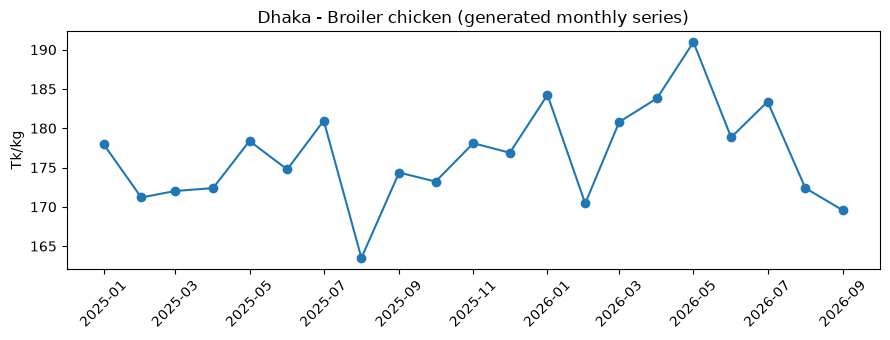

In [5]:
import matplotlib.pyplot as plt

check = monthly_df[(monthly_df.location == "Dhaka") & (monthly_df.commodity == "Broiler chicken")]
plt.figure(figsize=(9, 3.5))
plt.plot(check["date"], check["price_per_kg"], marker="o")
plt.title("Dhaka - Broiler chicken (generated monthly series)")
plt.ylabel("Tk/kg")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()